<a href="https://colab.research.google.com/github/AleksiOikarinen/Schoolwork-New/blob/main/Data_Analysis_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
from mpl_toolkits.mplot3d import Axes3D
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

df = pd.read_csv("C:\\Users\\aleks\\Desktop\\archive\\Movie_Data_File.csv")

df = df.drop(columns=["Release_year"])
df = df.drop(columns=["Owner_rating"])
sampled_df = df.sample(n=200, random_state=42)
print('Rivien ja sarakkeiden määrä:', df.shape)

Rivien ja sarakkeiden määrä: (10002, 27)


Poistimme tuotanto vuodet sillä ne olivat NaN. Owner rating ei myöskään tarjonnut mitään kiinostavaa tietoa. Totesimme myös että visualisoinnissa 10000 merkkiä on vaikea lukea joten päätimme ottaa 200 satunnaista elokuvaa

In [ ]:
print(df.isna().sum())
df = df.drop_duplicates()
df.sample(5)


Film_title             0
Director              10
Cast                  57
Average_rating       581
Genres                24
Runtime               10
Countries            118
Original_language      3
Spoken_languages       3
Description            2
Studios              307
Watches                0
List_appearances       0
Likes                  0
Fans                   0
½                      0
★                      0
★½                     0
★★                     0
★★½                    0
★★★                    0
★★★½                   0
★★★★                   0
★★★★½                  0
★★★★★                  0
Total_ratings          0
Film_URL               0
dtype: int64


,Film_title,Director,Cast,Average_rating,Genres,Runtime,Countries,Original_language,Spoken_languages,Description,...,★½,★★,★★½,★★★,★★★½,★★★★,★★★★½,★★★★★,Total_ratings,Film_URL
1292,American Made,Doug Liman,"['Tom Cruise', 'Domhnall Gleeson', 'Sarah Wrig...",3.41,"['Comedy', 'Crime', 'Drama']",115.0,"['USA', 'Luxembourg']",English,"['English', 'Spanish', 'French']","The true story of pilot Barry Seal, who transp...",...,1134,6024,11101,40777,46941,34498,5390,4538,151639,https://letterboxd.com/film/american-made/
446,Memories,"Katsuhiro Otomo, Koji Morimoto","['Tsutomu Isobe', 'Koichi Yamadera', 'Shozo Ii...",3.97,"['Animation', 'Fantasy', 'Science Fiction']",113.0,['Japan'],Japanese,['Japanese'],"In this anime anthology, a salvage ship crew h...",...,78,421,925,4707,9262,16957,5309,5202,42940,https://letterboxd.com/film/memories/
8097,The One and Only Ivan,Thea Sharrock,"['Bryan Cranston', 'Sam Rockwell', 'Brooklynn ...",2.95,"['Comedy', 'Family', 'Drama']",93.0,['USA'],English,['English'],A gorilla named Ivan who’s living in a suburba...,...,538,1908,2970,5500,2479,1468,229,460,16006,https://letterboxd.com/film/the-one-and-only-i...
3010,Attila,Pietro Francisci,"['Anthony Quinn', 'Sophia Loren', 'Henri Vidal...",NaN,"['War', 'Drama']",79.0,"['France', 'Italy']",Italian,['Italian'],"Attila, the leader of the barbarian Huns and c...",...,16,26,42,42,20,17,1,4,178,https://letterboxd.com/film/attila-1954/
1545,Alexander,Oliver Stone,"['Colin Farrell', 'Angelina Jolie', 'Val Kilme...",2.73,"['Drama', 'Action', 'History', 'Romance', 'Adv...",175.0,"['France', 'Germany', 'Netherlands', 'UK', 'US...",English,['English'],"Alexander, the King of Macedonia, leads his le...",...,3051,9036,8683,12504,5931,4782,984,1783,50531,https://letterboxd.com/film/alexander/


Ensin printtasimme kuinka monta tulosta on NaN jonka jälkeen poistamme kaikki toistuvat arvot. sitten sampleemme 5 satunnaista elokuvaa että lukeminen on helpompaa

<Figure size 1000x600 with 0 Axes>

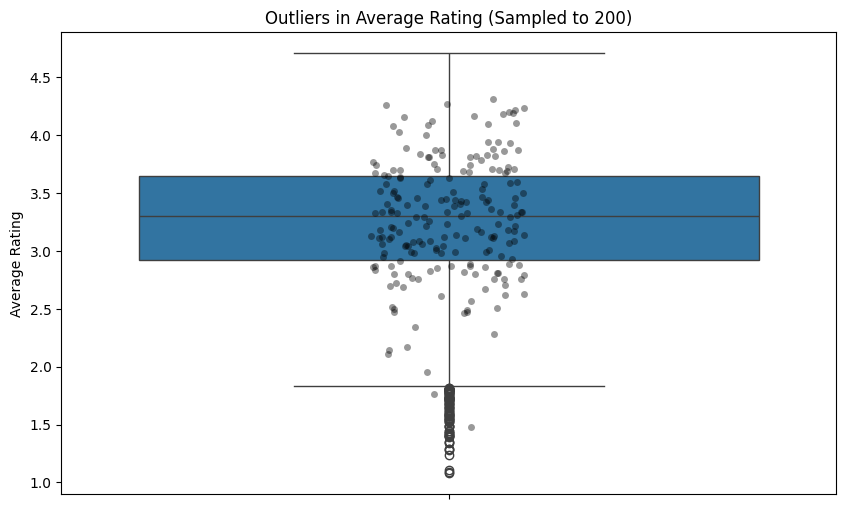

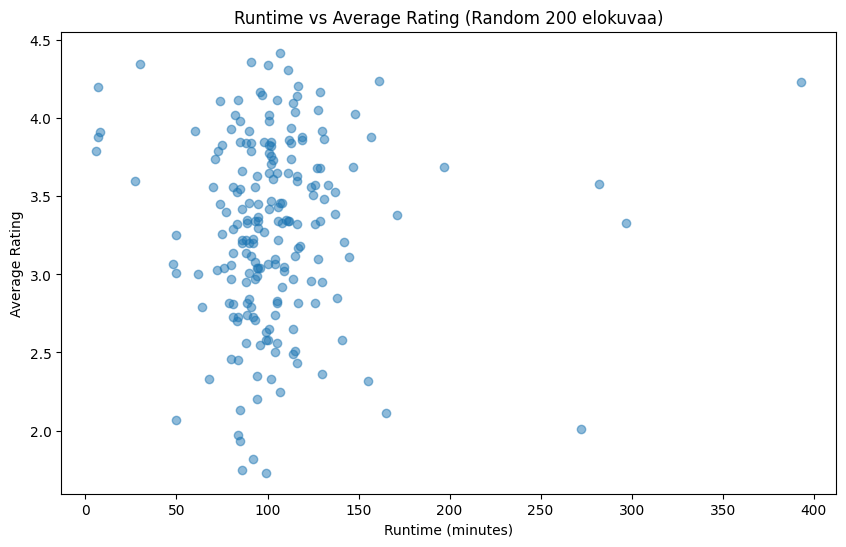

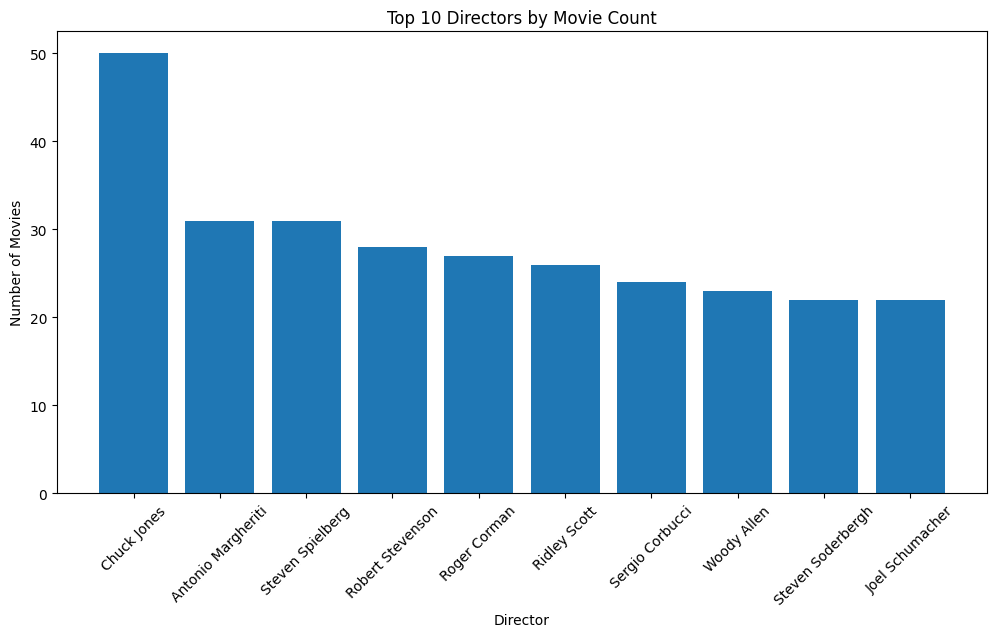

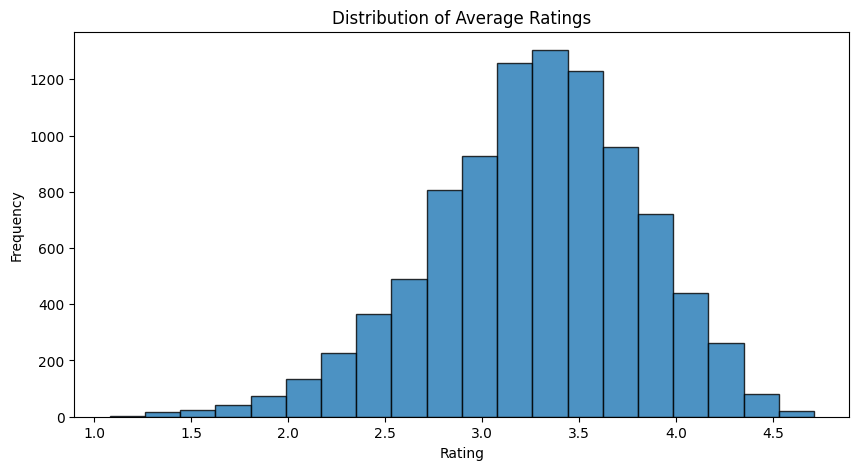

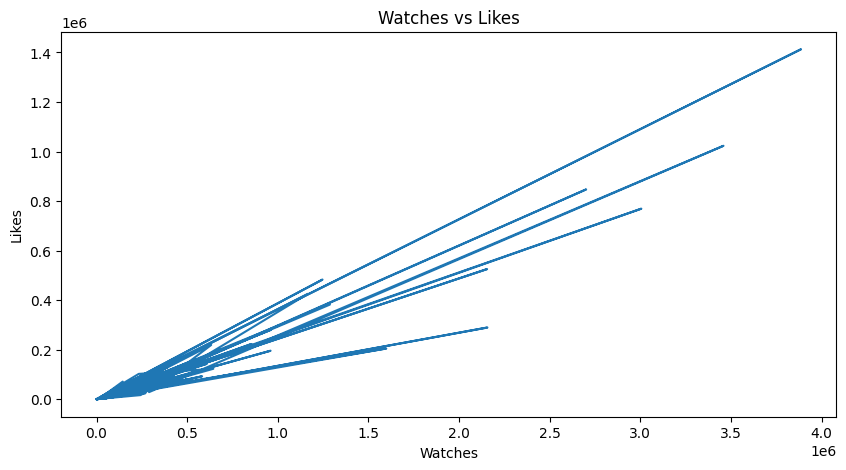

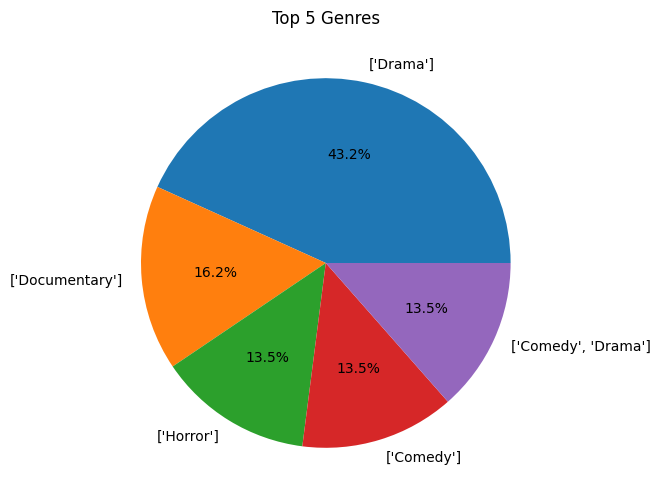

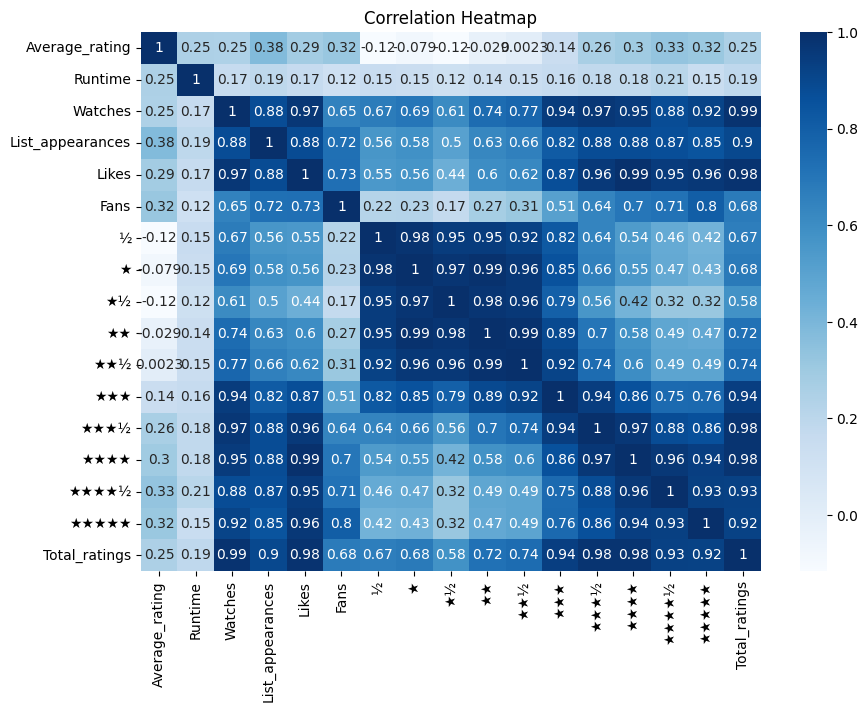

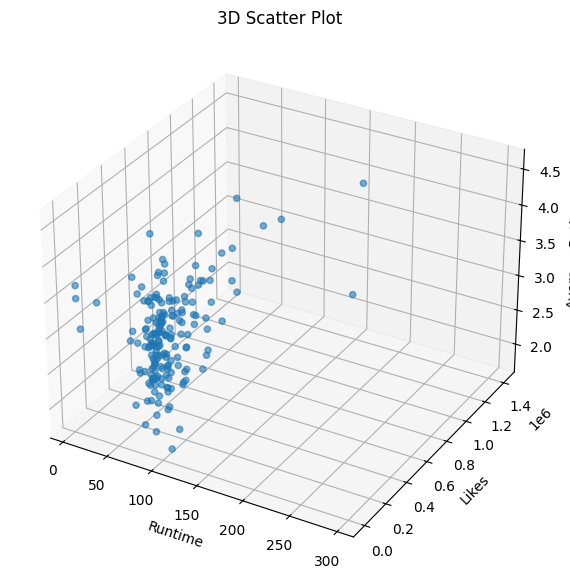

In [4]:

df['Director'] = df['Director'].fillna("Unknown")
df = df.dropna(subset=['Average_rating'])

df["Rating_bin"] = pd.qcut(
    df["Average_rating"],
    q=4,
    labels=["Low", "Below Average", "Above Average", "High"]
)


plt.figure(figsize=(10, 6))

sample = df['Average_rating'].sample(200)

#OG

plt.figure(figsize=(10, 6))
sns.boxplot(y=df['Average_rating'])
sns.stripplot(y=sample, color="black", alpha=0.4)
plt.title("Outliers in Average Rating (Sampled to 200)")
plt.ylabel("Average Rating")
plt.show()


#Scatter plot
sample = df.sample(200)

plt.figure(figsize=(10, 6))
plt.scatter(sample["Runtime"], sample["Average_rating"], alpha=0.5)

plt.title("Runtime vs Average Rating (Random 200 elokuvaa)")
plt.xlabel("Runtime (minutes)")
plt.ylabel("Average Rating")
plt.show()


#Bar chart
plt.figure(figsize=(12,6))
top_directors = df['Director'].value_counts().head(10)

plt.bar(top_directors.index, top_directors.values)
plt.title("Top 10 Directors by Movie Count")
plt.xlabel("Director")
plt.ylabel("Number of Movies")
plt.xticks(rotation=45)
plt.show()


#Histogram
plt.figure(figsize=(10,5))
plt.hist(df["Average_rating"], bins=20, edgecolor="black",linewidth=1,alpha=0.8)

plt.title("Distribution of Average Ratings")
plt.xlabel("Rating")
plt.ylabel("Frequency")
plt.show()

#Line plot
plt.figure(figsize=(10,5))
plt.plot(sampled_df["Watches"], sampled_df["Likes"])
plt.title("Watches vs Likes")
plt.xlabel("Watches")
plt.ylabel("Likes")
plt.show()

#Pie chart
genre_counts = sampled_df["Genres"].value_counts().head(5)

plt.figure(figsize=(6,6))
plt.pie(genre_counts, labels=genre_counts.index, autopct="%1.1f%%")
plt.title("Top 5 Genres")
plt.show()

#Heatmap
numeric_df = sampled_df.select_dtypes(include=[np.number])

plt.figure(figsize=(10,7))
sns.heatmap(numeric_df.corr(), annot=True, cmap="Blues")
plt.title("Correlation Heatmap")
plt.show()

#3D plot

fig = plt.figure(figsize=(10,7))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(sampled_df["Runtime"], sampled_df["Likes"], sampled_df["Average_rating"], alpha=0.6)

ax.set_xlabel("Runtime")
ax.set_ylabel("Likes")
ax.set_zlabel("Average Rating")
plt.title("3D Scatter Plot")
plt.show()


Tässä yritimme muuta tapaa kuin poistaa kaikki NaN arvot director kohdassa korvaamalla ne Unknownilla. sitten poistamme Avarage_rating arvot jos ne puuttuivat. jonka jälkeen teimme binnauksen. jonka jälkeen siirryimme visualisoimaan 200 satunnaista elokuvaa sillä 10000 pistettä visualisoinnissa oli aika hankalaa lukea tai ymmärtää.

In [5]:
#Binnaus

print("\nHead with Rating_bin:")
print(df[["Average_rating", "Rating_bin"]].head())

print("\nValue counts for bins:")
print(df["Rating_bin"].value_counts())



Head with Rating_bin:
   Average_rating     Rating_bin
0            3.57  Above Average
1            4.18           High
2            3.93           High
3            3.79           High
4            4.28           High

Value counts for bins:
Rating_bin
Below Average    2389
Low              2349
High             2339
Above Average    2315
Name: count, dtype: int64


Tässä kohdassa otamme aikaiseman binnauksen käyttöön ja printtaamme sen tuloksen.

In [6]:
#Attribute types

ordinal_columns = ["Rating_bin"]
types = {
    "Nominaali": [],
    "Ordinaali": [],
    "Binaari": []
}
for col in df.columns:
  unique_vals = df[col].dropna().unique()
  n_unique = len(unique_vals)
  dtype = df[col].dtype

  if col in ordinal_columns:
    types["Ordinaali"].append(col)

  elif n_unique == 2:
    types["Binaari"].append(col)

  elif dtype == "object":
    types["Nominaali"].append(col)

print("Nominaalit:", types["Nominaali"])
print("Ordinaalit:", types["Ordinaali"])
print("Binaarit:", types["Binaari"])

Nominaalit: ['Film_title', 'Director', 'Cast', 'Genres', 'Countries', 'Original_language', 'Spoken_languages', 'Description', 'Studios', 'Film_URL']
Ordinaalit: ['Rating_bin']
Binaarit: []


Tässä kohdassa erottelemme kaikki käytetyt arvot niidenkuuluville atribuuteille. totesimme että 10/11 atribuuteistamme ovat Nominaaleja ja vain yksi on Ordinaali. Ajattelimme että vain Original_language voisi mahdollisesti olla Binaari jos se olisi kysymys että onko elokuva käännetty vai alkuperäiskielellään.

In [ ]:
#Max rating
Highest_rating = np.max(df['Average_rating'])
print('Highest rating:', Highest_rating)

#Min rating
Lowest_rating = np.min(df['Average_rating'])
print('Lowest rating:', Lowest_rating)

#Laske sarakkeiden keskiarvot ja mediaaniarvot
mean_rating = np.mean(df['Average_rating'])
print('The mean rating of Average_rating:', mean_rating)

median_rating = np.median(df['Average_rating'])
print('The median rating of Average_rating:', median_rating)

#laskee datan keskihajonnan ja varianssin
std_dev_rating = np.std(df['Average_rating'], ddof = 1)
print("The sample standard deviation of Average_rating:", std_dev_rating)

variance_rating = np.var(df['Average_rating'])
print("The variance of Average_rating:", variance_rating)

#laskee datan summan ja tulon
sum_watches = np.sum(df['Watches'])
print("Total amount of watches across all of the movies:", sum_watches)


Highest rating: 4.71
Lowest rating: 1.08
The mean rating of Average_rating: 3.269162052810903
The median rating of Average_rating: 3.3
The sample standard deviation of Average_rating: 0.5418558510543774
The variance of Average_rating: 0.29357650184791545
Total amount of watches across all of the movies: 1700211170


Lopuksi käytimme kaikkia annettuja NumPy koodeja josta emme saaneet kauhestai kiinnostavaa tietoa muuta kuin kokonais katsoja määrän joka oli runsaat 1.7 miljardia, sekä Korkeimmain ja alimman ratingin